In [ ]:
import tempfile
from pathlib import Path
import pandas as pd
import norgatedata
from tqdm.auto import tqdm
%load_ext autoreload
%autoreload 2

In [ ]:
"""
builds a survivorship-bias-free universe matrix for backtesting.

returns:
- dataframe with dates as index and tickers as columns.
    cells contain 1 if the stock was in the index on that date, 0 otherwise.
"""

indexname = 'S&P 500'
symbols = norgatedata.watchlist_symbols(f'{indexname} Current & Past')  # get all snp500 symbols from past and present
calendar = norgatedata.price_timeseries('$SPX', timeseriesformat='pandas-dataframe').index  # gets the full trading calendar

last_trading_day = calendar[-1]
universe_df = []

for symbol in tqdm(symbols, desc='building universe'):
    idx = norgatedata.index_constituent_timeseries(symbol, indexname, timeseriesformat="pandas-dataframe")
    if idx['Index Constituent'].sum() > 0:  # checks if the symbol is in the index ('1') at that time
        idx = idx.rename(columns={'Index Constituent': symbol})
        idx = idx.loc[idx[symbol] == 1]
        # Important: remove the past days
        if last_trading_day != idx.index[-1]:
            idx = idx.iloc[:-5]

        universe_df.append(idx)

universe_df = pd.concat(universe_df, axis=1).fillna(0).astype(int).sort_index()


building universe:   0%|          | 0/1275 [00:00<?, ?it/s]

In [3]:
display(universe_df)

,A,AABA-201910,AAL,AAL-199702,AAMRQ-201312,AAP,AAPL,AAV-199901,ABBV,ABI-200811,...,XYL,YELLQ,YNR-200010,YUM,ZBH,ZBRA,ZE-199805,ZION,ZRN-199806,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-02,0,0,0,1,1,0,1,1,0,1,...,0,1,0,0,0,0,1,0,1,0
1990-01-03,0,0,0,1,1,0,1,1,0,1,...,0,1,0,0,0,0,1,0,1,0
1990-01-04,0,0,0,1,1,0,1,1,0,1,...,0,1,0,0,0,0,1,0,1,0
1990-01-05,0,0,0,1,1,0,1,1,0,1,...,0,1,0,0,0,0,1,0,1,0
1990-01-08,0,0,0,1,1,0,1,1,0,1,...,0,1,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-16,1,0,0,0,0,0,1,0,1,0,...,1,0,0,1,1,1,0,0,0,1
2025-05-19,1,0,0,0,0,0,1,0,1,0,...,1,0,0,1,1,1,0,0,0,1
2025-05-20,1,0,0,0,0,0,1,0,1,0,...,1,0,0,1,1,1,0,0,0,1


In [4]:
def qp_indicator(close, window=3, lookback_years=5):
    try:
        rets = close.pct_change(periods=window)
    except ValueError as e:
        return pd.Series(index=close.index)

    def rolling_rank(x):
        return (x.rank(pct=True).iloc[-1])

    rolling_rank = rets.rolling(window=lookback_years * 252).apply(rolling_rank, raw=False)
    rolling_down = rets.rolling(window=lookback_years * 252).apply(lambda x: (x <= 0).sum())
    prob_down = rolling_down / (lookback_years * 252)
    prob_up = 1 - prob_down

    idx_down = rets[rets <= 0].index
    idx_up = rets[rets > 0].index

    qp = pd.Series(index=close.index)
    qp.loc[idx_down] = rolling_rank / prob_down
    qp.loc[idx_up] = (1 - rolling_rank) / prob_up
    qp *= 100
    return qp

In [5]:
benchmarks = ['$SPX']  # define benchmark symbols (e.g., S&P 500 index)
pricing_data = []

# loop through all symbols (stocks + benchmarks)
for symbol in tqdm(symbols + benchmarks):
    # use total return adjustment for benchmarks, capital/special adjustments for stocks
    if symbol in benchmarks:
        adjs = norgatedata.StockPriceAdjustmentType.TOTALRETURN
    else:
        adjs = norgatedata.StockPriceAdjustmentType.CAPITALSPECIAL

    # download price data with full market day padding from 1998 onward
    p = norgatedata.price_timeseries(
        symbol,
        stock_price_adjustment_setting=adjs,
        padding_setting=norgatedata.PaddingType.ALLMARKETDAYS,
        start_date='1998-01-01',
        timeseriesformat='pandas-dataframe',
    )
    
    # skip if no data returned
    if len(p) == 0:
        continue

    # for stock symbols only, compute features needed for the strategy
    if symbol in symbols:
        p['bwd_return'] = p['Close'].pct_change()                 # 1-day return
        p['3d_bwd_return'] = p['Close'].pct_change(periods=3)     # 3-day return
        p['qp_indicator'] = qp_indicator(p['Close'], window=3, lookback_years=5)  # Custom QPI metric
        p['sma_200'] = p['Close'].rolling(window=200).mean()         # 200-day simple moving average

    # add a MultiIndex to columns to identify data by symbol
    p.columns = pd.MultiIndex.from_tuples([(symbol, c) for c in p.columns])
    pricing_data.append(p)

# combine all pricing data into a single DataFrame, sorted by date
pricing_data = pd.concat(pricing_data, axis=1).sort_index()

  0%|          | 0/1276 [00:00<?, ?it/s]

In [6]:
pricing_data

A                                                 \
                  Open        High         Low       Close     Volume   
Date                                                                    
1998-01-02         NaN         NaN         NaN         NaN        NaN   
1998-01-05         NaN         NaN         NaN         NaN        NaN   
1998-01-06         NaN         NaN         NaN         NaN        NaN   
1998-01-07         NaN         NaN         NaN         NaN        NaN   
1998-01-08         NaN         NaN         NaN         NaN        NaN   
...                ...         ...         ...         ...        ...   
2025-05-16  112.279999  113.830002  110.820000  113.769997  1811966.0   
2025-05-19  112.500000  113.470001  112.029999  113.440002  2086318.0   
2025-05-20  113.449997  114.139999  112.660004  113.480003  2245800.0   
2025-05-21  112.000000  112.605003  108.699997  108.910004  2859893.0   
2025-05-22  108.360001  110.190002  107.964996  109.680000  2232739.0   

                                                                            \
               Turnover Unadjusted Close Dividend bwd_return 3d_bwd_return   
Date                                                                         
1998-01-02          NaN              NaN      NaN        NaN           NaN   
1998-01-05          NaN              NaN      NaN        NaN           NaN   
1998-01-06          NaN              NaN      NaN        NaN           NaN   
1998-01-07          NaN              NaN      NaN        NaN           NaN   
1998-01-08          NaN              NaN      NaN        NaN           NaN   
...                 ...              ...      ...        ...           ...   
2025-05-16  205316672.0       113.769997      0.0   0.012189     -0.014296   
2025-05-19  236030864.0       113.440002      0.0  -0.002901      0.017217   
2025-05-20  254862864.0       113.480003      0.0   0.000353      0.009609   
2025-05-21  313915040.0       108.910004      0.0  -0.040271     -0.042718   
2025-05-22  244516272.0       109.680000      0.0   0.007070     -0.033145   

            ...        ZTS                                               $SPX  \
            ... bwd_return 3d_bwd_return qp_indicator    sma_200         Open   
Date        ...                                                                 
1998-01-02  ...        NaN           NaN          NaN        NaN   970.429993   
1998-01-05  ...        NaN           NaN          NaN        NaN   975.210022   
1998-01-06  ...        NaN           NaN          NaN        NaN   977.070007   
1998-01-07  ...        NaN           NaN          NaN        NaN   966.580017   
1998-01-08  ...        NaN           NaN          NaN        NaN   964.000000   
...         ...        ...           ...          ...        ...          ...   
2025-05-16  ...   0.016776      0.016395    47.813411  172.83230  5929.089844   
2025-05-19  ...   0.005520      0.058224     4.512373  172.75180  5902.879883   
2025-05-20  ...  -0.001769      0.020580    37.936047  172.65795  5944.660156   
2025-05-21  ...  -0.013504     -0.009813    67.190227  172.56220  5910.180176   
2025-05-22  ...   0.003283     -0.012017    61.324042  172.49795  5841.259766   

                                                                               
                   High          Low        Close        Volume      Turnover  
Date                                                                           
1998-01-02   975.039978   965.729980   975.000000  3.456000e+08  1.763940e+10  
1998-01-05   982.630005   969.000000   977.070007  5.793000e+08  3.036510e+10  
1998-01-06   977.070007   962.679993   966.580017  5.329000e+08  2.743250e+10  
1998-01-07   966.580017   952.669983   964.000000  5.869000e+08  2.988470e+10  
1998-01-08   964.000000   955.039978   956.039978  5.720000e+08  2.874980e+10  
...                 ...          ...          ...           ...           ...  
2025-05-16  5958.620117  5907.359863  5958.379883 

In [ ]:
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


from collections import defaultdict
from alpha.engine.strategy import Strategy


class QPIStrategy(Strategy):
    max_positions = 4  # maximum number of positions to hold
    trade_id = 0  # intiliazing trade_id to 0
    current_trade = defaultdict(lambda: -1)  # initializing current_trade as a defaultdict of lists with default value -1
    universe_df = None  # df storing the universe of stocks

    def compute_signals(self, pricing_data: pd.DataFrame) -> pd.DataFrame:
        """
        this method is meant to generate trading signals but is currently 
        a placeholder. it will be implemented to process price data and 
        identify trade opportunities.
        """
        # in our case, we are already calculated this in the previous step during data ingestion
        return pricing_data  # currently returns raw pricing data (to be modified).

    def iterate(self, data: pd.DataFrame, close: pd.DataFrame, open_prices: pd.Series):
        """
        this method will contain the logic for executing trades based on 
        the strategy rules. it must be implemented to place buy and sell orders 
        according to QPI and price conditions.
        """

        # get current porfolio positions
        positions = self.get_positions()
        long_positions = positions[positions > 0]
        long_slots = self.max_positions - len(long_positions)  # calculate available slots for new positions

        # exit rules
        """ exit logic: sell if price > yesterday's high """
        for symbol in long_positions.index:
            c = close[(symbol, 'Close')]
            yh = data[(symbol, 'High')].iloc[-2]
            if c > yh:
                self.order_target_value(symbol, 0, trade_id=self.current_trade[symbol])
                long_slots += 1


        # entry rules
        capital_to_allocate_per_trade = self.previous_total_value / self.max_positions  # each trade receives an equal share of the portfolio
        long_opportunities = self.get_opportunities(close)

        while long_slots > 0 and len(long_opportunities) > 0:
            symbol = long_opportunities.pop(0)  # pips the top-ranked stock from opportunities

            # skip if already holding this stock (for safety)
            if self.get_position(symbol) != 0:
                continue

            # assign new trade_id and log it
            self.trade_id += 1
            self.current_trade[symbol] = self.trade_id

            # place buy order with equal capital allocation
            self.order_value(symbol, capital_to_allocate_per_trade, trade_id=self.trade_id)

            long_slots -= 1  # reduce available slots

    def get_opportunities(self, close) -> list:
        """ 
        identifying and ranking the best trade opportunities based on our entry criteria
        """
        # unstack multi-index DataFrame to have symbols as index and features as columns
        df = close.unstack().dropna()

        # remove benchmark symbols (e.g., $SPX) from the dataset
        df = df[~df.index.astype(str).str.startswith('$')]

        # apply entry filters:
        # - QPI indicator below 15 (signal of extreme decline)
        # - Price above 200-day SMA (uptrend condition)
        # - 3-day return is negative (confirm recent decline)
        # then sort by turnover in descending order for liquidity ranking
        df = df[
            (df['qp_indicator'] < 15) &
            (df['Close'] > df['sma_200']) &
            (df['3d_bwd_return'] < 0)
        ].sort_values('Turnover', ascending=False)

        # get the list of stocks in the universe on the previous trading day
        u = self.universe_df.loc[self.previous_bar]
        u = u[u == 1].index.tolist()

        # return the filtered list of opportunity tickers that are also in the universe
        return df[df.index.isin(u)].index.tolist()



In [ ]:
from alpha.engine.backtest import run_daily
from IPython.display import display

sa = QPIStrategy(
    name='QPIStrategy',
    capital_base=100_000,
    benchmarks=['$SPX'],
    slippage=0.0001
)
sa.universe_df = universe_df

calendar = pricing_data.index
calendar = calendar[calendar.year >= 2004]

run_daily(sa, pricing_data, calendar)

sa.universe_df = None

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(sa.summary)
display(sa.summary_trades)
tmp = Path(tempfile.gettempdir())
sa.to_pickle(tmp / f'{sa.name}.pkl')
sa.plot('$SPX', 'S&P 500', save_to=tmp / f'{sa.name}.png')

In [9]:
# genereate a monthly report

from alpha.engine.metrics import generate_monthly_returns
mr = generate_monthly_returns(sa.results['total_value'], add_sharpe_ratios=True, add_max_drawdowns=True)
for c in mr.columns[:-1]:
    mr[c] = mr[c].apply(lambda x: f'{x:.1%}' if not pd.isna(x) else "")
mr['Sharpe Ratio'] = mr['Sharpe Ratio'].apply(lambda x: f'{x:.2f}' if not pd.isna(x) else "")
mr


month,1,2,3,4,5,6,7,8,9,10,11,12,Annual Return,Max Drawdown,Sharpe Ratio
year,,,,,,,,,,,,,,,
2025,5.5%,-1.3%,-4.2%,1.9%,5.3%,,,,,,,,7.1%,-21.5%,0.67
2024,-0.3%,3.7%,0.4%,1.1%,5.1%,5.8%,5.2%,2.8%,2.6%,2.3%,8.8%,-1.0%,42.6%,-6.3%,2.08
2023,-4.7%,7.0%,6.0%,6.2%,-3.8%,4.4%,11.1%,-2.6%,-4.6%,-1.6%,5.6%,6.6%,31.7%,-11.0%,1.68
2022,-4.2%,0.7%,2.7%,-4.9%,-0.2%,-1.5%,7.5%,3.3%,-11.4%,9.7%,6.1%,-1.2%,4.8%,-15.3%,0.31
2021,-1.3%,-0.1%,16.0%,-1.5%,-2.5%,-3.9%,-4.0%,-3.7%,-3.3%,10.5%,-8.1%,10.7%,6.0%,-19.7%,0.36
2020,-0.2%,-7.2%,-3.5%,28.4%,6.9%,9.2%,6.5%,2.4%,0.5%,-3.3%,19.4%,0.1%,69.7%,-26.8%,1.68
2019,-0.2%,2.3%,5.1%,2.9%,-11.2%,12.4%,6.6%,2.9%,0.2%,2.5%,5.9%,3.3%,35.7%,-11.6%,1.90
2018,11.0%,-0.5%,-2.2%,-3.3%,7.4%,-1.0%,-2.0%,1.5%,1.4%,-9.3%,-0.4%,-5.1%,-3.9%,-22.6%,-0.07
2017,1.2%,6.3%,2.9%,3.3%,3.4%,1.6%,0.2%,-4.8%,2.6%,1.8%,2.2%,2.2%,25.0%,-10.1%,1.57


In [10]:
sa._transactions

,trade_id,bar,asset,amount,price,total_value,order_id
0,1,2004-01-06,KBH,727,34.378437,2.499312e+04,1
1,2,2004-01-06,HUM,1173,21.302129,2.498740e+04,2
2,3,2004-01-08,CCTYQ-201109,2786,8.995211,2.506066e+04,3
3,4,2004-01-08,CTAS,2150,11.655788,2.505995e+04,4
4,2,2004-01-13,HUM,-1173,20.997900,-2.463054e+04,5
...,...,...,...,...,...,...,...
8143,4071,2025-05-19,GILD,-9731,102.989700,-1.002193e+06,8144
8144,4073,2025-05-21,FICO,506,1964.796436,9.941870e+05,8145
8145,4074,2025-05-22,AXP,3367,285.658568,9.618124e+05,8146
8146,4075,2025-05-22,MS,7719,124.617464,9.619222e+05,8147


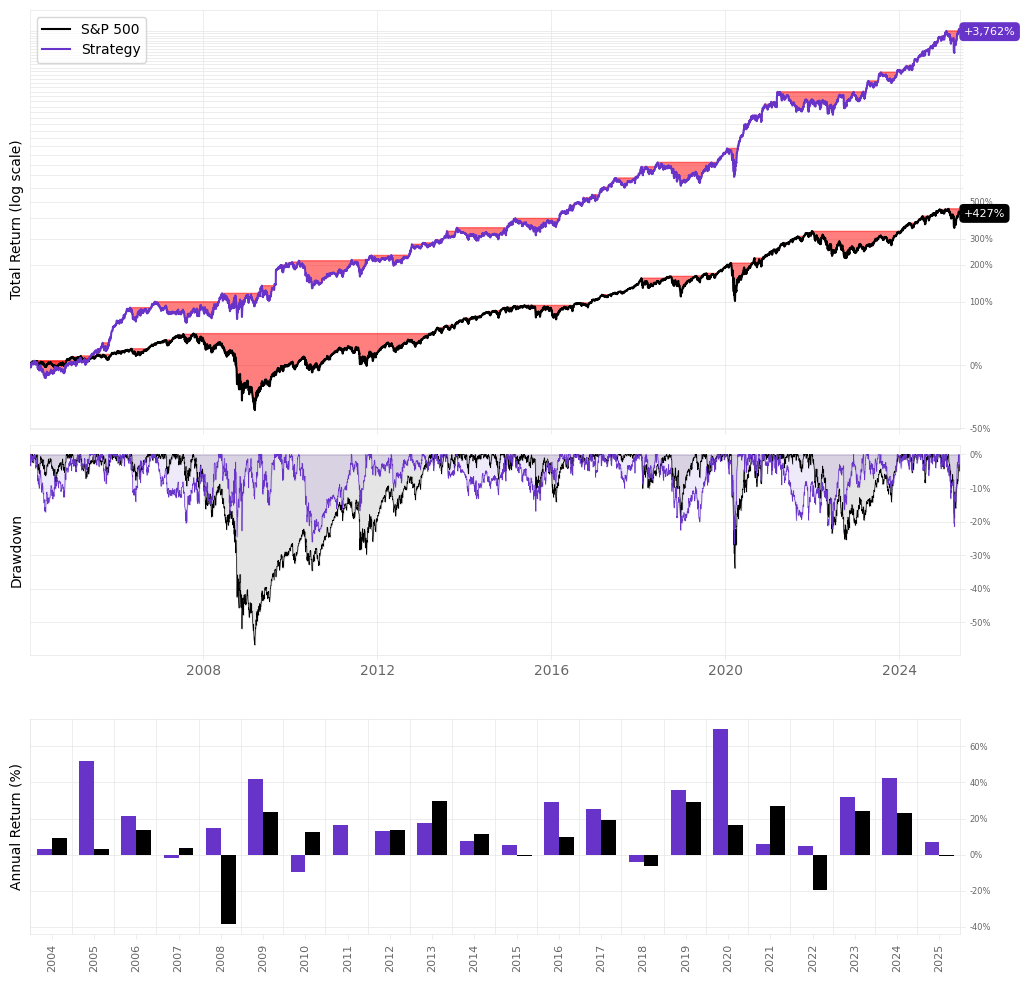

In [31]:
sa.plot('$SPX', 'S&P 500')